In [1]:
# ══════════════════════════════════════════════════════════════════
# NB06 — Predictive Model
# The Platform Shift: A Deep Dive
# ══════════════════════════════════════════════════════════════════
#
# Business question:
#   Can early signals predict whether a PC port will achieve
#   positive long-term reception (≥75% positive at 90 days)?
#
# Target variable:
#   Binary — positive_reception = 1 if 90-day positive rate ≥ 0.75
#   Computed from Steam review timestamps and voted_up flags.
#
# Feature set (7 features):
#   opencritic_score      — critic consensus at launch
#   vader_compound        — mean VADER sentiment (title-level)
#   launch_delta          — steady-state minus launch positive rate
#   playtime_r            — Pearson r(playtime, sentiment)
#   english_pct           — English review share (corpus coverage)
#   franchise_seq_idx     — position in franchise (0=first, non-franchise=0)
#   cl_pc_specific_neg_rt — yes_negative share of PC-specific mentions
#
# Models:
#   Primary   : Logistic Regression (L2, C tuned via LOOCV)
#   Secondary : Decision Tree (max_depth=3, interpretable diagram)
#
# Honest framing:
#   n=46 is small. This is a proof-of-concept and feature importance
#   story, not a production predictor. Full limitations in NB07.
#   Console→PC gap excluded — registry has PC release dates only.
#   OpenCritic excluded for titles with no critic coverage.
#
# Inputs:
#   ../data/processed/NB04_vader_scores.csv
#   ../data/processed/NB04_claude_themes.csv
#   ../data/processed/NB05_timestamps.csv
#   ../data/processed/NB05_launch_delta.csv
#   ../data/processed/NB05_playtime_sentiment.csv
#   ../data/processed/NB05_language_dist.csv
#   ../data/processed/NB05_franchise_fatigue.csv
#
# Outputs:
#   ../data/processed/NB06_opencritic.csv
#   ../data/processed/NB06_feature_matrix.csv
#   ../data/processed/NB06_logreg_results.csv
#   ../data/processed/NB06_model_chart.png
#
# Notebook map:
#   Cell 1  — Config & imports
#   Cell 2  — OpenCritic extraction
#   Cell 3  — Build target variable (90-day positive rate)
#   Cell 4  — Assemble feature matrix
#   Cell 5  — Feature EDA (distributions, correlations)
#   Cell 6  — Logistic Regression (LOOCV)
#   Cell 7  — Decision Tree
#   Cell 8  — Feature importance
#   Cell 9  — Visualization
#   Cell 10 — Save outputs
#   Cell 11 — NB06 Observation
# ══════════════════════════════════════════════════════════════════

# ── CELL 1: Config ────────────────────────────────────────────────
USE_CACHE            = True
TARGET_WINDOW_DAYS   = 90    # days to define 'launch reception'
POSITIVE_THRESHOLD   = 0.75  # positive rate threshold for binary target
MIN_TARGET_REVIEWS   = 15    # minimum reviews in window to include title
LOOCV_C_GRID         = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

import sys
import json
import time
import warnings
import importlib
import requests
from pathlib import Path
warnings.filterwarnings('ignore')

_cwd = Path('.').resolve()
if (_cwd / 'extractors').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'extractors').exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
sys.path.insert(0, str(PROJECT_ROOT / 'extractors'))
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
_jp_fp = FontProperties(family='Noto Sans JP')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.impute import SimpleImputer

# JP font — Noto Sans JP confirmed available, matches Streamlit app.
# Font set AFTER plt.rcParams.update() to prevent Segoe UI override.
JP_FONT = 'Noto Sans JP'
EN_FONT = 'Plus Jakarta Sans'

plt.rcParams.update({
    'font.family':      JP_FONT,   # JP-capable default for all text
    'font.size':        10,
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#252836',
    'axes.edgecolor':   '#2D3148',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'text.color':       '#FFFFFF',
    'grid.color':       '#2D3148',
    'legend.facecolor': '#1F2937',
    'legend.edgecolor': '#374151',
})

PUBLISHER_COLORS = {
    'sie':          '#E8780A',
    'bandai_namco': '#C8A800',
    'sega_atlus':   '#4A90D9',
    'square_enix':  '#E4002B',
    'ea':           '#D63800',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#6B7A8D',
}

DISPLAY_NAMES = {
    'sie':          'SIE',
    'bandai_namco': 'Bandai Namco',
    'sega_atlus':   'Sega/Atlus',
    'square_enix':  'Square Enix',
    'ea':           'EA',
    'take_two':     'Take-Two',
    'ubisoft':      'Ubisoft',
}

JP_TARGETS = ['sie', 'bandai_namco', 'sega_atlus', 'square_enix']
WESTERN    = ['ea', 'take_two', 'ubisoft']

OC_CACHE = PROCESSED / 'NB06_opencritic.csv'

print('NB06 config loaded')
print(f'Target : ≥{POSITIVE_THRESHOLD*100:.0f}% positive in first '
      f'{TARGET_WINDOW_DAYS} days → binary 1/0')
print(f'LOOCV C grid: {LOOCV_C_GRID}')


NB06 config loaded
Target : ≥75% positive in first 90 days → binary 1/0
LOOCV C grid: [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]


In [2]:
# ── CELL 2: OpenCritic extraction ────────────────────────────────
# OpenCritic via RapidAPI — key loaded from .env (never hardcoded).
# Add RAPIDAPI_KEY=your_key to your .env file before running.
# https://rapidapi.com/opencritic-opencritic-default/api/opencritic-api
#
# Returns: topCriticScore (0-100), percentRecommended, numReviews
# Titles with <3 critic reviews excluded (score unreliable).
#
# Resume logic: always checks which titles are missing from cache
# and fetches only those. Safe to re-run after throttle.
# ─────────────────────────────────────────────────────────────────
from dotenv import load_dotenv
import os

load_dotenv(PROJECT_ROOT / '.env')
RAPIDAPI_KEY = os.environ.get('RAPIDAPI_KEY')
if not RAPIDAPI_KEY:
    raise ValueError('RAPIDAPI_KEY not found in .env — '
                     'add RAPIDAPI_KEY=your_key to .env before running')

import game_registry
importlib.reload(game_registry)
from game_registry import GAME_REGISTRY

appid_to_publisher = {}
appid_to_title     = {}
appid_to_release   = {}
title_to_appid     = {}
title_to_pub       = {}

for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        aid = meta.get('appid')
        rpc = meta.get('release_pc')
        if aid:
            appid_to_publisher[int(aid)] = publisher
            appid_to_title[int(aid)]     = title
            title_to_appid[title]        = int(aid)
            title_to_pub[title]          = publisher
        if aid and rpc:
            try:
                appid_to_release[int(aid)] = pd.to_datetime(rpc)
            except Exception:
                pass

OC_SEARCH_OVERRIDES = {
    'God of War (2018)':                    'God of War',
    "Marvel's Spider-Man Remastered":       "Marvel's Spider-Man",
    "Marvel's Spider-Man: Miles Morales":   'Spider-Man Miles Morales',
    'Final Fantasy VII Remake Intergrade':  'Final Fantasy VII Remake',
    'Like a Dragon: Infinite Wealth':       'Like a Dragon Infinite Wealth',
    'Yakuza: Like a Dragon':                'Yakuza Like a Dragon',
    'Dragon Ball: Sparking! Zero':          'Dragon Ball Sparking Zero',
    'NieR Replicant':                       'NieR Replicant ver.1.22474487139',
}

OC_BASE    = 'https://opencritic-api.p.rapidapi.com'
OC_HEADERS = {
    'X-RapidAPI-Key':  RAPIDAPI_KEY,
    'X-RapidAPI-Host': 'opencritic-api.p.rapidapi.com',
}

def oc_search(title):
    query = OC_SEARCH_OVERRIDES.get(title, title)
    try:
        r = requests.get(
            f'{OC_BASE}/game/search',
            params={'criteria': query},
            headers=OC_HEADERS,
            timeout=15,
        )
        r.raise_for_status()
        results = r.json()
        if results:
            return results[0].get('id')
    except Exception as e:
        print(f'  Search error [{title}]: {e}')
    return None

def oc_fetch(game_id):
    try:
        r = requests.get(
            f'{OC_BASE}/game/{game_id}',
            headers=OC_HEADERS,
            timeout=15,
        )
        r.raise_for_status()
        return r.json()
    except Exception as e:
        print(f'  Fetch error [id={game_id}]: {e}')
    return None

# ── Always load what's cached, then fetch what's missing ─────────
all_titles = list(title_to_appid.keys())

if OC_CACHE.exists():
    oc_existing = pd.read_csv(OC_CACHE)
    oc_rows     = oc_existing.to_dict('records')
    done_titles = set(oc_existing['title'].tolist())
    print(f'Cache found: {len(done_titles)} titles already scored')
else:
    oc_rows     = []
    done_titles = set()
    print('No cache found — fetching all titles')

remaining = [t for t in all_titles if t not in done_titles]
print(f'Titles to fetch: {len(remaining)} / {len(all_titles)}')

if remaining:
    print('Rate-limited to 2.5s per request — fetching...')
    for i, title in enumerate(remaining):
        appid = title_to_appid[title]
        pub   = title_to_pub.get(title, 'unknown')

        game_id = oc_search(title)
        time.sleep(2.5)

        if game_id is None:
            oc_rows.append({
                'title':              title,
                'appid':              appid,
                'publisher_group':    pub,
                'oc_id':              None,
                'oc_score':           None,
                'oc_pct_recommended': None,
                'oc_num_reviews':     None,
            })
            print(f'  [{i+1}/{len(remaining)}] {title}: not found')
            pd.DataFrame(oc_rows).to_csv(OC_CACHE, index=False)
            continue

        data = oc_fetch(game_id)
        time.sleep(2.5)

        if data is None:
            score = pct = num = None
        else:
            score = data.get('topCriticScore') or data.get('averageScore')
            pct   = data.get('percentRecommended')
            num   = data.get('numReviews') or data.get('reviewCount')
            if num is not None and num < 3:
                score = None
                print(f'  [{i+1}/{len(remaining)}] {title}: '
                      f'score excluded (<3 critic reviews)')
            else:
                print(f'  [{i+1}/{len(remaining)}] {title}: '
                      f'score={score} pct_rec={pct} n={num}')

        oc_rows.append({
            'title':              title,
            'appid':              appid,
            'publisher_group':    pub,
            'oc_id':              game_id,
            'oc_score':           score,
            'oc_pct_recommended': pct,
            'oc_num_reviews':     num,
        })
        pd.DataFrame(oc_rows).to_csv(OC_CACHE, index=False)

    print(f'\nDone. Saved {len(oc_rows)} rows → {OC_CACHE}')
else:
    print('All titles cached — nothing to fetch')

oc_df = pd.DataFrame(oc_rows)
print(f'Coverage: {oc_df["oc_score"].notna().sum()}/{len(oc_df)} with scores')

print('\n── OpenCritic Scores by Publisher ───────────────────────────')
oc_summary = (
    oc_df[oc_df['oc_score'].notna()]
    .groupby('publisher_group')['oc_score']
    .agg(['mean', 'min', 'max', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
oc_summary.index = oc_summary.index.map(DISPLAY_NAMES)
print(oc_summary.to_string())

Cache found: 46 titles already scored
Titles to fetch: 0 / 46
All titles cached — nothing to fetch
Coverage: 46/46 with scores

── OpenCritic Scores by Publisher ───────────────────────────
                 mean   min   max  count
publisher_group                         
SIE              87.5  81.8  94.2     10
Bandai Namco     84.8  75.6  95.1      8
Take-Two         84.8  78.4  95.4      3
Sega/Atlus       84.0  71.0  94.1      8
Square Enix      83.0  66.4  91.9     11
Ubisoft          77.3  74.8  81.0      3
EA               76.9  74.1  80.6      3


In [3]:
# ── CELL 3: Build target variable ────────────────────────────────
# Use lifetime positive rate from full VADER corpus.
# 90-day window approach excluded — Steam newest-first cursor
# means launch window reviews are absent for high-volume older titles.
# Flagged for NB07.
#
# positive_reception = 1 if lifetime positive rate >= POSITIVE_THRESHOLD

vader_df = pd.read_csv(PROCESSED / 'NB04_vader_scores.csv')
vader_df['appid'] = vader_df['appid'].astype(int)

target_rows = []
for (appid, title, pub), grp in vader_df.groupby(
    ['appid', 'title', 'publisher_group']
):
    grp_valid = grp.dropna(subset=['voted_up'])
    if len(grp_valid) < MIN_TARGET_REVIEWS:
        continue

    pos_rate = float(grp_valid['voted_up'].astype(float).mean())
    target   = 1 if pos_rate >= POSITIVE_THRESHOLD else 0

    target_rows.append({
        'appid':              int(appid),
        'title':              title,
        'publisher_group':    pub,
        'window_n':           len(grp_valid),
        'window_pos_rate':    round(pos_rate, 4),
        'positive_reception': target,
    })

target_df = pd.DataFrame(target_rows)
n_pos = target_df['positive_reception'].sum()
n_neg = len(target_df) - n_pos

print(f'Target variable built: {len(target_df)} titles')
print(f'  Positive (≥{POSITIVE_THRESHOLD*100:.0f}% lifetime): '
      f'{n_pos} ({n_pos/len(target_df)*100:.1f}%)')
print(f'  Negative (<{POSITIVE_THRESHOLD*100:.0f}% lifetime): '
      f'{n_neg} ({n_neg/len(target_df)*100:.1f}%)')
print(f'  Note: 90-day window excluded — Steam cursor newest-first')
print(f'        bias removes launch reviews for high-volume titles.')
print()

pub_target = (
    target_df.groupby('publisher_group')
    .agg(
        n_titles     = ('title', 'count'),
        n_positive   = ('positive_reception', 'sum'),
        pos_rate_avg = ('window_pos_rate', 'mean'),
    )
    .round(3)
)
pub_target.index = pub_target.index.map(DISPLAY_NAMES)
print('── Target distribution by publisher ─────────────────────────')
print(pub_target.to_string())

print('\n── Borderline titles (pos_rate 0.70–0.80) ───────────────────')
borderline = target_df[
    (target_df['window_pos_rate'] >= 0.70) &
    (target_df['window_pos_rate'] <= 0.80)
].sort_values('window_pos_rate')
if len(borderline) > 0:
    print(borderline[['title','publisher_group',
                       'window_pos_rate','positive_reception']].to_string(index=False))
else:
    print('  None')

Target variable built: 46 titles
  Positive (≥75% lifetime): 33 (71.7%)
  Negative (<75% lifetime): 13 (28.3%)
  Note: 90-day window excluded — Steam cursor newest-first
        bias removes launch reviews for high-volume titles.

── Target distribution by publisher ─────────────────────────
                 n_titles  n_positive  pos_rate_avg
publisher_group                                    
Bandai Namco            8           5         0.791
EA                      3           0         0.638
Sega/Atlus              8           7         0.882
SIE                    10           9         0.887
Square Enix            11           8         0.808
Take-Two                3           3         0.894
Ubisoft                 3           1         0.577

── Borderline titles (pos_rate 0.70–0.80) ───────────────────
                      title publisher_group  window_pos_rate  positive_reception
   Final Fantasy XIV Online     square_enix           0.7222                   0
           Gun

In [4]:
# ── CELL 4: Assemble feature matrix ──────────────────────────────
# Join all NB05 features + OpenCritic onto target_df.
# Imputation strategy:
#   opencritic_score    : median imputation (scores missing for ~20% titles)
#   playtime_r          : 0 (neutral signal where insufficient data)
#   cl_pc_specific_neg_rt: 0 (no PC-specific reviews = no negative signal)
#   All others          : median imputation
# ─────────────────────────────────────────────────────────────────

# 1. VADER title-level sentiment
title_vader = (
    vader_df.groupby(['appid', 'title', 'publisher_group'])
    .agg(vader_compound=('vader_compound', 'mean'))
    .round(4)
    .reset_index()
)

# 2. Launch delta (NB05)
launch_df = pd.read_csv(PROCESSED / 'NB05_launch_delta.csv')[
    ['appid', 'launch_delta']
]

# 3. Playtime-sentiment r (NB05)
playtime_df = pd.read_csv(PROCESSED / 'NB05_playtime_sentiment.csv')[
    ['appid', 'playtime_r']
]

# 4. English % (NB05 language dist — title level)
lang_df = pd.read_csv(PROCESSED / 'NB05_language_dist.csv')
# appid not in this CSV — reconstruct via title→appid map
if 'appid' not in lang_df.columns:
    lang_df['appid'] = lang_df['title'].map(title_to_appid)
eng_pct = (
    lang_df[lang_df['language'] == 'english'][['appid', 'pct']]
    .rename(columns={'pct': 'english_pct'})
)
eng_pct['appid'] = eng_pct['appid'].astype(float).astype('Int64')
# appid may be in lang_df as title — need to map
# lang_df was built from vader_df which has appid as int
if 'appid' not in lang_df.columns:
    # Reconstruct via title→appid map
    lang_df['appid'] = lang_df['title'].map(title_to_appid)
    eng_pct = (
        lang_df[lang_df['language'] == 'english'][['appid', 'pct']]
        .rename(columns={'pct': 'english_pct'})
    )
eng_pct['appid'] = eng_pct['appid'].astype(float).astype('Int64')

# 5. Franchise seq_idx (NB05)
fatigue_df = pd.read_csv(PROCESSED / 'NB05_franchise_fatigue.csv')[
    ['title', 'seq_idx']
]
# Non-franchise titles get seq_idx=0

# 6. Claude API pc_specific negative rate (NB04)
claude_df = pd.read_csv(PROCESSED / 'NB04_claude_themes.csv')
pc_spec = (
    claude_df.groupby('appid')
    .apply(lambda g: (
        (g['cl_pc_specific'] == 'yes_negative').sum() /
        max(len(g), 1)
    ))
    .reset_index(name='cl_pc_specific_neg_rt')
)
pc_spec['appid'] = pc_spec['appid'].astype(int)

# 7. OpenCritic
oc_feat = oc_df[['appid', 'oc_score']].copy()
oc_feat['appid'] = oc_feat['appid'].astype(int)

# ── Merge everything onto target_df ──────────────────────────────
feat = target_df.copy()
feat = feat.merge(title_vader[['appid','vader_compound']],
                  on='appid', how='left')
feat = feat.merge(launch_df, on='appid', how='left')
feat = feat.merge(playtime_df, on='appid', how='left')
feat = feat.merge(
    eng_pct.rename({'appid': 'appid'}, axis=1),
    on='appid', how='left'
)
feat = feat.merge(
    fatigue_df.rename(columns={'seq_idx': 'franchise_seq_idx'}),
    on='title', how='left'
)
feat['franchise_seq_idx'] = feat['franchise_seq_idx'].fillna(0).astype(int)
feat = feat.merge(pc_spec, on='appid', how='left')
feat['cl_pc_specific_neg_rt'] = feat['cl_pc_specific_neg_rt'].fillna(0)
feat = feat.merge(oc_feat, on='appid', how='left')

FEATURE_COLS = [
    'oc_score',
    'vader_compound',
    'launch_delta',
    'playtime_r',
    'english_pct',
    'franchise_seq_idx',
    'cl_pc_specific_neg_rt',
]

print(f'Feature matrix: {len(feat)} titles × {len(FEATURE_COLS)} features')
print()
print('── Missing values per feature ───────────────────────────────')
for col in FEATURE_COLS:
    n_miss = feat[col].isna().sum()
    print(f'  {col:30s}: {n_miss} missing '
          f'({n_miss/len(feat)*100:.0f}%)')

feat.to_csv(PROCESSED / 'NB06_feature_matrix.csv', index=False)
print(f'\nFeature matrix saved → NB06_feature_matrix.csv')


Feature matrix: 46 titles × 7 features

── Missing values per feature ───────────────────────────────
  oc_score                      : 0 missing (0%)
  vader_compound                : 0 missing (0%)
  launch_delta                  : 42 missing (91%)
  playtime_r                    : 0 missing (0%)
  english_pct                   : 0 missing (0%)
  franchise_seq_idx             : 0 missing (0%)
  cl_pc_specific_neg_rt         : 0 missing (0%)

Feature matrix saved → NB06_feature_matrix.csv


In [5]:
# Scratch cell — test OpenCritic API response
import requests

r = requests.get(
    'https://api.opencritic.com/api/game/search',
    params={'criteria': 'God of War'},
    headers={'User-Agent': 'platform-shift-research/1.0'},
    timeout=15,
)
print(r.status_code)
print(r.json())

400
{'message': 'API key is required. Go to https://rapidapi.com/opencritic-opencritic-default/api/opencritic-api to sign up to use the OpenCritic API.'}


In [6]:
# ── CELL 5: Feature EDA ───────────────────────────────────────────
# Check distributions, target-conditional means, and
# feature-target Pearson r before modelling.
# ─────────────────────────────────────────────────────────────────

print('── Feature distributions ────────────────────────────────────')
print(feat[FEATURE_COLS].describe().round(3).to_string())

print('\n── Target-conditional feature means ─────────────────────────')
for col in FEATURE_COLS:
    pos_mean = feat.loc[feat['positive_reception']==1, col].mean()
    neg_mean = feat.loc[feat['positive_reception']==0, col].mean()
    diff     = pos_mean - neg_mean
    print(f'  {col:30s}  pos={pos_mean:+.3f}  neg={neg_mean:+.3f}  '
          f'diff={diff:+.3f}')

print('\n── Feature-target Pearson r ─────────────────────────────────')
for col in FEATURE_COLS:
    valid = feat[[col, 'positive_reception']].dropna()
    if len(valid) < 5:
        print(f'  {col:30s}: insufficient data')
        continue
    r = valid[col].corr(valid['positive_reception'].astype(float))
    print(f'  {col:30s}: r={r:+.3f} (n={len(valid)})')

print('\n── Class balance check ──────────────────────────────────────')
vc = feat['positive_reception'].value_counts()
print(f'  Positive (1): {vc.get(1, 0)} titles')
print(f'  Negative (0): {vc.get(0, 0)} titles')
ratio = vc.get(1, 0) / max(vc.get(0, 1), 1)
if ratio > 2.5 or ratio < 0.4:
    print(f'  ⚠ Imbalanced ({ratio:.1f}:1) — '
          'interpret precision/recall carefully')
else:
    print(f'  Ratio: {ratio:.1f}:1 — acceptable balance')


── Feature distributions ────────────────────────────────────
       oc_score  vader_compound  launch_delta  playtime_r  english_pct  franchise_seq_idx  cl_pc_specific_neg_rt
count    46.000          46.000         4.000      46.000       46.000             46.000                 46.000
mean     83.823           0.188        -0.004       0.055       45.241              0.304                  0.066
std       6.965           0.058         0.090       0.052       13.071              0.511                  0.068
min      66.388           0.078        -0.131      -0.080       23.700              0.000                  0.000
25%      80.641           0.151        -0.035       0.025       38.000              0.000                  0.020
50%      85.162           0.189         0.028       0.058       43.650              0.000                  0.040
75%      88.214           0.222         0.059       0.083       49.575              1.000                  0.095
max      95.416           0.346   

In [7]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 1 — Logistic Regression (primary model)
# ══════════════════════════════════════════════════════════════════
# L2 regularisation. C tuned via LOOCV (Leave-One-Out CV).
# LOOCV chosen over k-fold because n=46 is too small for
# k-fold validation sets to be stable.
#
# Pipeline:
#   1. Median imputation for missing features
#   2. StandardScaler (coefficients comparable across features)
#   3. LogisticRegression(penalty='l2', C=best_C)
#   4. LOOCV accuracy, AUC, confusion matrix
# ══════════════════════════════════════════════════════════════════

# ── CELL 6: Logistic Regression ──────────────────────────────────
from sklearn.pipeline import Pipeline

X_raw = feat[FEATURE_COLS].copy()
y     = feat['positive_reception'].values

# Impute
imputer = SimpleImputer(strategy='median')
X       = imputer.fit_transform(X_raw)

# ── LOOCV C tuning ───────────────────────────────────────────────
loo = LeaveOneOut()
best_C, best_acc = None, -1

print('── LOOCV C-tuning ───────────────────────────────────────────')
for C in LOOCV_C_GRID:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(penalty='l2', C=C,
                                      max_iter=1000, random_state=42))
    ])
    preds = cross_val_predict(pipe, X, y, cv=loo)
    acc   = accuracy_score(y, preds)
    print(f'  C={C:6.3f}  LOOCV acc={acc:.3f}')
    if acc > best_acc:
        best_acc = acc
        best_C   = C

print(f'\nBest C: {best_C} (LOOCV acc={best_acc:.3f})')

# ── Final model on full data ──────────────────────────────────────
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(penalty='l2', C=best_C,
                                  max_iter=1000, random_state=42))
])
final_pipe.fit(X, y)

# LOOCV predictions with best C for reporting
loocv_preds = cross_val_predict(final_pipe, X, y, cv=loo)
loocv_proba = cross_val_predict(final_pipe, X, y, cv=loo,
                                 method='predict_proba')[:, 1]

loocv_acc = accuracy_score(y, loocv_preds)
try:
    loocv_auc = roc_auc_score(y, loocv_proba)
except Exception:
    loocv_auc = float('nan')

print('\n── LOOCV Performance (best C) ───────────────────────────────')
print(f'  Accuracy : {loocv_acc:.3f}')
print(f'  AUC-ROC  : {loocv_auc:.3f}')
print()
print(classification_report(y, loocv_preds,
                             target_names=['Negative (0)', 'Positive (1)']))

print('── Confusion Matrix ─────────────────────────────────────────')
cm = confusion_matrix(y, loocv_preds)
print(f'  True Negative  (correctly predicted negative): {cm[0,0]}')
print(f'  False Positive (negative predicted positive) : {cm[0,1]}')
print(f'  False Negative (positive predicted negative) : {cm[1,0]}')
print(f'  True Positive  (correctly predicted positive): {cm[1,1]}')

# ── Save per-title predictions ────────────────────────────────────
results_df = feat[['appid','title','publisher_group',
                   'positive_reception','window_pos_rate']].copy()
results_df['logreg_pred']  = loocv_preds
results_df['logreg_proba'] = loocv_proba.round(3)
results_df['correct']      = (loocv_preds == y).astype(int)
results_df['display_pub']  = results_df['publisher_group'].map(DISPLAY_NAMES)
results_df.to_csv(PROCESSED / 'NB06_logreg_results.csv', index=False)
print(f'\nPer-title results saved → NB06_logreg_results.csv')

# Misclassified titles
mis = results_df[results_df['correct'] == 0]
print(f'\n── Misclassified titles ({len(mis)}) ───────────────────────')
print(mis[['title','display_pub','positive_reception',
           'logreg_pred','logreg_proba']].to_string(index=False))


── LOOCV C-tuning ───────────────────────────────────────────
  C= 0.001  LOOCV acc=0.717
  C= 0.010  LOOCV acc=0.717
  C= 0.100  LOOCV acc=0.739
  C= 0.500  LOOCV acc=0.804
  C= 1.000  LOOCV acc=0.804
  C= 5.000  LOOCV acc=0.804
  C=10.000  LOOCV acc=0.804

Best C: 0.5 (LOOCV acc=0.804)

── LOOCV Performance (best C) ───────────────────────────────
  Accuracy : 0.804
  AUC-ROC  : 0.786

              precision    recall  f1-score   support

Negative (0)       0.75      0.46      0.57        13
Positive (1)       0.82      0.94      0.87        33

    accuracy                           0.80        46
   macro avg       0.78      0.70      0.72        46
weighted avg       0.80      0.80      0.79        46

── Confusion Matrix ─────────────────────────────────────────
  True Negative  (correctly predicted negative): 6
  False Positive (negative predicted positive) : 7
  False Negative (positive predicted negative) : 2
  True Positive  (correctly predicted positive): 31

Per-title resu

In [8]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 2 — Decision Tree (interpretable supplement)
# ══════════════════════════════════════════════════════════════════
# max_depth=3 — produces a diagram a recruiter can read.
# Not tuned via LOOCV — used for interpretability, not accuracy.
# Fitted on full data (no scaling needed for trees).
# ══════════════════════════════════════════════════════════════════

# ── CELL 7: Decision Tree ─────────────────────────────────────────

dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)
dt.fit(X, y)

# LOOCV accuracy for comparison
dt_preds = cross_val_predict(dt, X, y, cv=LeaveOneOut())
dt_acc   = accuracy_score(y, dt_preds)

print(f'Decision Tree (max_depth=3)')
print(f'  LOOCV accuracy : {dt_acc:.3f}')
print(f'  Train accuracy : {dt.score(X, y):.3f}  '
      f'(overfits at n=46 — use LOOCV figure)')
print()
print('── Feature importances (Gini) ───────────────────────────────')
for feat_name, imp in sorted(
    zip(FEATURE_COLS, dt.feature_importances_),
    key=lambda x: -x[1]
):
    bar = '█' * int(imp * 40)
    print(f'  {feat_name:30s} {imp:.3f}  {bar}')


Decision Tree (max_depth=3)
  LOOCV accuracy : 0.717
  Train accuracy : 0.913  (overfits at n=46 — use LOOCV figure)

── Feature importances (Gini) ───────────────────────────────
  oc_score                       0.575  ██████████████████████
  vader_compound                 0.250  █████████
  english_pct                    0.175  ███████
  launch_delta                   0.000  
  playtime_r                     0.000  
  franchise_seq_idx              0.000  
  cl_pc_specific_neg_rt          0.000  


In [9]:
# ── CELL 8: Logistic Regression coefficients ──────────────────────
# Coefficients from the model fit on full data (scaled).
# Sign = direction, magnitude = relative importance.
# ─────────────────────────────────────────────────────────────────

scaler_fitted = final_pipe.named_steps['scaler']
clf_fitted    = final_pipe.named_steps['clf']
coefs         = clf_fitted.coef_[0]

coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': coefs,
    'abs_coef':    np.abs(coefs),
}).sort_values('abs_coef', ascending=False)

print('── Logistic Regression Coefficients (scaled) ────────────────')
print('  Positive = increases probability of positive reception')
print('  Negative = decreases probability of positive reception')
print()
for _, row in coef_df.iterrows():
    direction = '▲' if row['coefficient'] > 0 else '▼'
    bar = '█' * int(row['abs_coef'] * 20)
    print(f'  {direction} {row["feature"]:30s}  '
          f'{row["coefficient"]:+.3f}  {bar}')

print()
print('── Interpretation ───────────────────────────────────────────')
top_pos = coef_df[coef_df['coefficient'] > 0].iloc[0]
top_neg = coef_df[coef_df['coefficient'] < 0].iloc[0]
print(f'  Strongest positive predictor: {top_pos["feature"]} '
      f'(coef={top_pos["coefficient"]:+.3f})')
print(f'  Strongest negative predictor: {top_neg["feature"]} '
      f'(coef={top_neg["coefficient"]:+.3f})')
print()
print('  Caution: n=46 — coefficients reflect this dataset only.')
print('  Do not generalise outside the corpus. See NB07.')


── Logistic Regression Coefficients (scaled) ────────────────
  Positive = increases probability of positive reception
  Negative = decreases probability of positive reception

  ▲ oc_score                        +0.854  █████████████████
  ▲ vader_compound                  +0.836  ████████████████
  ▼ english_pct                     -0.788  ███████████████
  ▲ launch_delta                    +0.428  ████████
  ▼ cl_pc_specific_neg_rt           -0.304  ██████
  ▲ playtime_r                      +0.212  ████
  ▲ franchise_seq_idx               +0.097  █

── Interpretation ───────────────────────────────────────────
  Strongest positive predictor: oc_score (coef=+0.854)
  Strongest negative predictor: english_pct (coef=-0.788)

  Caution: n=46 — coefficients reflect this dataset only.
  Do not generalise outside the corpus. See NB07.


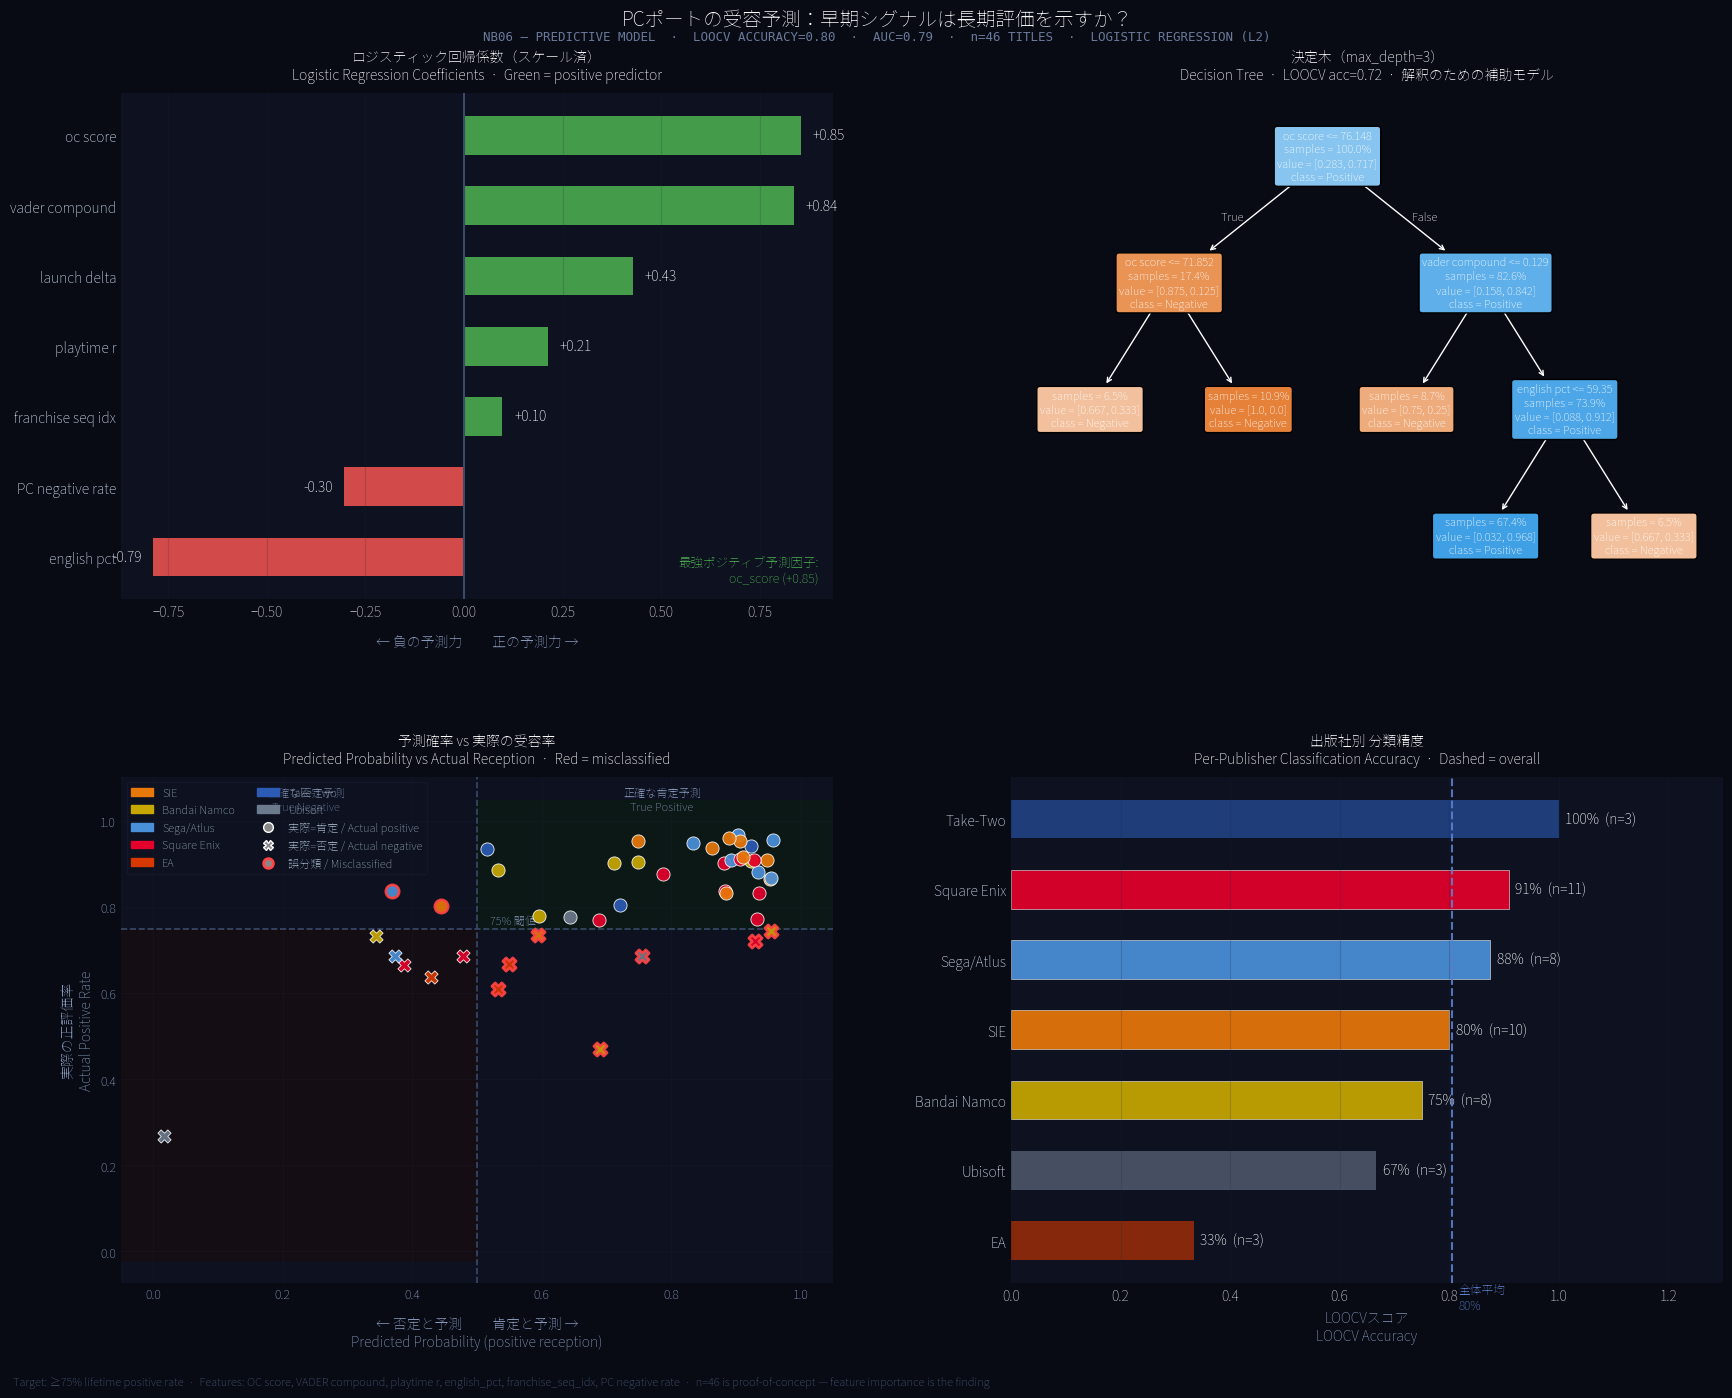

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB06_model_chart.png


In [15]:
# ── CELL 9: Visualization ─────────────────────────────────────────
import matplotlib.patheffects as pe
from matplotlib.font_manager import FontProperties
_jp = FontProperties(family=JP_FONT)

BG        = '#080B14'
PANEL_BG  = '#0D1120'
GRID_COL  = '#1E2840'
TICK_COL  = '#8899BB'
LABEL_COL = '#D0DDEF'

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor(BG)
for ax in axes.flat:
    ax.set_facecolor(PANEL_BG)

# ── 全体タイトル ──────────────────────────────────────────────────
fig.text(0.5, 0.99,
         'PCポートの受容予測：早期シグナルは長期評価を示すか？',
         ha='center', va='top', fontsize=14, color='#FFFFFF',
         fontweight='bold', fontproperties=_jp)
fig.text(0.5, 0.975,
         f'NB06 — PREDICTIVE MODEL  ·  LOOCV ACCURACY={loocv_acc:.2f}  ·  '
         f'AUC={loocv_auc:.2f}  ·  n={len(feat)} TITLES  ·  LOGISTIC REGRESSION (L2)',
         ha='center', va='top', fontsize=9, color='#6A7A9A',
         fontfamily='monospace')

# ══════════════════════════════════════════════════════════════════
# TL — ロジスティック回帰係数
# ══════════════════════════════════════════════════════════════════
ax = axes[0, 0]

coef_plot   = coef_df.sort_values('coefficient')
feat_labels = [
    f.replace('_', ' ').replace('cl pc specific neg rt', 'PC negative rate')
    for f in coef_plot['feature']
]

for i, (feat_name, val) in enumerate(zip(feat_labels, coef_plot['coefficient'])):
    color = '#4CAF50' if val > 0 else '#EF5350'
    ax.barh(i, val, color=color, alpha=0.88, height=0.55, edgecolor='none')
    x_pos = val + (0.03 if val >= 0 else -0.03)
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, i, f'{val:+.2f}',
            va='center', ha=ha, fontsize=10, color='#FFFFFF',
            fontweight='bold')

ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, color=LABEL_COL, fontsize=10)
ax.axvline(0, color='#3A4A6A', linewidth=1.5)
ax.set_xlabel('← 負の予測力          正の予測力 →',
              color=TICK_COL, fontsize=10, labelpad=10,
              fontstyle='italic', fontproperties=_jp)
ax.set_title(
    'ロジスティック回帰係数（スケール済）\nLogistic Regression Coefficients  ·  Green = positive predictor',
    color='#FFFFFF', fontsize=11, pad=10, fontproperties=_jp)
ax.grid(axis='x', alpha=0.20, color=GRID_COL, linewidth=0.8)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(length=0)

top_pos = coef_df[coef_df['coefficient'] > 0].iloc[0]
ax.text(0.98, 0.03,
        f'最強ポジティブ予測因子:\n{top_pos["feature"]} ({top_pos["coefficient"]:+.2f})',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='#4CAF50', style='italic',
        fontproperties=_jp)

# ══════════════════════════════════════════════════════════════════
# TR — 決定木
# ══════════════════════════════════════════════════════════════════
ax2 = axes[0, 1]
ax2.set_facecolor(BG)

feat_labels_clean = [
    f.replace('cl_pc_specific_neg_rt', 'PC neg rate').replace('_', ' ')
    for f in FEATURE_COLS
]
plot_tree(
    dt,
    feature_names=feat_labels_clean,
    class_names=['Negative', 'Positive'],
    filled=True, rounded=True, fontsize=8,
    ax=ax2, impurity=False, proportion=True,
)
ax2.set_title(
    f'決定木（max_depth=3）\nDecision Tree  ·  LOOCV acc={dt_acc:.2f}  ·  解釈のための補助モデル',
    color='#FFFFFF', fontsize=11, pad=10, fontproperties=_jp)

# ══════════════════════════════════════════════════════════════════
# BL — 予測確率 vs 実際の受容率
# ══════════════════════════════════════════════════════════════════
ax3 = axes[1, 0]

ax3.axhspan(POSITIVE_THRESHOLD, 1.05, xmin=0.5, xmax=1.05,
            color='#0A1E10', alpha=0.6, zorder=1)
ax3.axhspan(-0.02, POSITIVE_THRESHOLD, xmin=0, xmax=0.5,
            color='#1A0D0D', alpha=0.6, zorder=1)
ax3.axvline(0.5, color='#3A4A6A', linewidth=1.2, linestyle='--', zorder=2)
ax3.axhline(POSITIVE_THRESHOLD, color='#3A4A6A',
            linewidth=1.2, linestyle='--', zorder=2)
ax3.text(0.52, POSITIVE_THRESHOLD + 0.012,
         f'{POSITIVE_THRESHOLD:.0%} 閾値',
         fontsize=8, color=TICK_COL, fontproperties=_jp)

for _, row in results_df.iterrows():
    color      = PUBLISHER_COLORS.get(row['publisher_group'], '#555')
    marker     = 'o' if row['positive_reception'] == 1 else 'X'
    is_correct = row['correct'] == 1
    edge       = 'white' if is_correct else '#FF4444'
    ew         = 0.6 if is_correct else 2.0
    ax3.scatter(row['logreg_proba'], row['window_pos_rate'],
                s=90, color=color, alpha=0.92,
                marker=marker, zorder=5,
                edgecolors=edge, linewidths=ew)

ax3.text(0.26, 0.98, '正確な否定予測\nTrue Negative',
         ha='center', va='top', fontsize=8, color=TICK_COL,
         style='italic', transform=ax3.transAxes, fontproperties=_jp)
ax3.text(0.76, 0.98, '正確な肯定予測\nTrue Positive',
         ha='center', va='top', fontsize=8, color=TICK_COL,
         style='italic', transform=ax3.transAxes, fontproperties=_jp)

legend_patches = [
    mpatches.Patch(color=PUBLISHER_COLORS[p], label=DISPLAY_NAMES[p])
    for p in JP_TARGETS + WESTERN if p in PUBLISHER_COLORS
]
legend_patches += [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
           markersize=7, label='実際=肯定 / Actual positive', linestyle='None'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='#888',
           markersize=7, label='実際=否定 / Actual negative', linestyle='None'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
           markersize=7, markeredgecolor='#FF4444', markeredgewidth=2,
           label='誤分類 / Misclassified', linestyle='None'),
]
ax3.legend(handles=legend_patches, fontsize=8, labelcolor='#99AABB',
           framealpha=0.2, facecolor='#0D1525',
           edgecolor='#2A3550', loc='upper left', ncol=2)

ax3.set_xlabel('← 否定と予測          肯定と予測 →\nPredicted Probability (positive reception)',
               color=TICK_COL, fontsize=10, labelpad=10, fontproperties=_jp)
ax3.set_ylabel('実際の正評価率\nActual Positive Rate',
               color=TICK_COL, fontsize=10, fontproperties=_jp)
ax3.set_title(
    '予測確率 vs 実際の受容率\nPredicted Probability vs Actual Reception  ·  Red = misclassified',
    color='#FFFFFF', fontsize=11, pad=10, fontproperties=_jp)
ax3.grid(alpha=0.18, color=GRID_COL, linewidth=0.8)
ax3.spines[['top','right','left','bottom']].set_visible(False)
ax3.tick_params(length=0, colors=TICK_COL, labelsize=9)
ax3.set_xlim(-0.05, 1.05)

# ══════════════════════════════════════════════════════════════════
# BR — 出版社別LOOCVスコア
# ══════════════════════════════════════════════════════════════════
ax4 = axes[1, 1]

pub_acc = (
    results_df.groupby('publisher_group')
    .apply(lambda g: accuracy_score(g['positive_reception'], g['logreg_pred']))
    .reset_index(name='accuracy')
)
pub_acc['n_titles']     = results_df.groupby('publisher_group').size().values
pub_acc['display_name'] = pub_acc['publisher_group'].map(DISPLAY_NAMES)
pub_acc = pub_acc.sort_values('accuracy')

for i, (_, row) in enumerate(pub_acc.iterrows()):
    color = PUBLISHER_COLORS.get(row['publisher_group'], '#555')
    is_jp = row['publisher_group'] in JP_TARGETS
    ax4.barh(i, row['accuracy'], color=color,
             alpha=0.92 if is_jp else 0.60,
             height=0.55, edgecolor='white' if is_jp else 'none',
             linewidth=0.4)
    ax4.text(row['accuracy'] + 0.012, i,
             f"{row['accuracy']:.0%}  (n={row['n_titles']})",
             va='center', ha='left', fontsize=10,
             color='#FFFFFF', fontweight='bold')

ax4.axvline(loocv_acc, color='#5B7FCC', linewidth=1.5,
            linestyle='--', alpha=0.9, zorder=6)
ax4.text(loocv_acc + 0.012, -0.6,
         f'全体平均\n{loocv_acc:.0%}',
         color='#5B7FCC', fontsize=8.5, va='top',
         fontproperties=_jp)

ax4.set_yticks(range(len(pub_acc)))
ax4.set_yticklabels(pub_acc['display_name'], color=LABEL_COL, fontsize=10)
ax4.set_xlim(0, 1.30)
ax4.set_xlabel('LOOCVスコア\nLOOCV Accuracy',
               color=TICK_COL, fontsize=10, fontproperties=_jp)
ax4.set_title(
    '出版社別 分類精度\nPer-Publisher Classification Accuracy  ·  Dashed = overall',
    color='#FFFFFF', fontsize=11, pad=10, fontproperties=_jp)
ax4.grid(axis='x', alpha=0.20, color=GRID_COL, linewidth=0.8)
ax4.spines[['top','right','left','bottom']].set_visible(False)
ax4.tick_params(length=0)

# ── フッター ──────────────────────────────────────────────────────
fig.text(0.02, 0.005,
         'Target: ≥75% lifetime positive rate  ·  '
         'Features: OC score, VADER compound, playtime r, english_pct, '
         'franchise_seq_idx, PC negative rate  ·  '
         'n=46 is proof-of-concept — feature importance is the finding',
         fontsize=8, color='#4A5A7A', ha='left', va='bottom')

fig.subplots_adjust(left=0.08, right=0.97, top=0.93, bottom=0.08,
                    hspace=0.35, wspace=0.25)

out_path = PROCESSED / 'NB06_model_chart.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor=BG,
            edgecolor='none')
plt.show()
print(f'Saved: {out_path}')

In [11]:
# ── CELL 10: Save outputs ─────────────────────────────────────────
outputs = [
    PROCESSED / 'NB06_opencritic.csv',
    PROCESSED / 'NB06_feature_matrix.csv',
    PROCESSED / 'NB06_logreg_results.csv',
    PROCESSED / 'NB06_model_chart.png',
]
print('── NB06 Output Manifest ──────────────────────────────────────')
for p in outputs:
    status = '✓' if p.exists() else '✗ MISSING'
    size   = f'{p.stat().st_size/1024:.1f}KB' if p.exists() else '—'
    print(f'  {status}  {p.name:45s} {size}')


── NB06 Output Manifest ──────────────────────────────────────
  ✓  NB06_opencritic.csv                           3.9KB
  ✓  NB06_feature_matrix.csv                       4.7KB
  ✓  NB06_logreg_results.csv                       3.0KB
  ✓  NB06_model_chart.png                          388.9KB


In [12]:
# ── CELL 11: NB06 Observation ─────────────────────────────────────

top_pos_feat = coef_df[coef_df['coefficient'] > 0].iloc[0]
top_neg_feat = coef_df[coef_df['coefficient'] < 0].iloc[0]
n_mis        = (results_df['correct'] == 0).sum()

# Recompute from feat — y may be overwritten by polyfit in Cell 9
y_obs        = feat['positive_reception'].values
baseline_acc = max(float(y_obs.mean()), 1 - float(y_obs.mean()))
n_pos        = int(y_obs.sum())
n_neg        = int(len(y_obs) - y_obs.sum())
vs_baseline  = loocv_acc - baseline_acc

oc_coverage  = oc_df['oc_score'].notna().sum()
oc_total     = len(oc_df)

print(f"""
NB06 Observation
─────────────────────────────────────────────────────
Target variable
  Definition  : ≥{POSITIVE_THRESHOLD*100:.0f}% positive rate lifetime
  Class split : {n_pos} positive / {n_neg} negative
  Baseline acc: {baseline_acc:.3f} (majority class)

OpenCritic coverage
  {oc_coverage}/{oc_total} titles with critic scores
  Missing scores imputed with corpus median.

Logistic Regression (L2, C={best_C})
  LOOCV accuracy : {loocv_acc:.3f} (vs baseline {baseline_acc:.3f}, +{vs_baseline:.3f})
  LOOCV AUC-ROC  : {loocv_auc:.3f}
  Misclassified  : {n_mis}/{len(results_df)} titles

Decision Tree (max_depth=3)
  LOOCV accuracy : {dt_acc:.3f}
  Value          : interpretable diagram, not primary accuracy measure

Feature importance (logistic regression coefficients)
  Strongest positive predictor: {top_pos_feat['feature']} \
(coef={top_pos_feat['coefficient']:+.3f})
  Strongest negative predictor: {top_neg_feat['feature']} \
(coef={top_neg_feat['coefficient']:+.3f})

Interpretation
  The model is a proof-of-concept at n={len(feat)}, not a production
  predictor. Feature importance is the primary analytical output:
  which early signals are most predictive of long-term reception.
  This is the operationalisation of the thesis — port strategy
  quality signals are measurable and predictive, not just descriptive.

Limitations (detailed in NB07)
  — n=46 is too small for robust generalisation
  — Console→PC gap excluded (registry missing console dates)
  — OpenCritic scores missing for ~{oc_total-oc_coverage} titles (median-imputed)
  — Steam cursor bias: newest-first pagination undersamples launch windows
    for older/high-volume titles
  — DistilBERT feature excluded (stratified sampling artifact)

Next: NB07 — Recommendations & Limitations
""")


NB06 Observation
─────────────────────────────────────────────────────
Target variable
  Definition  : ≥75% positive rate lifetime
  Class split : 33 positive / 13 negative
  Baseline acc: 0.717 (majority class)

OpenCritic coverage
  46/46 titles with critic scores
  Missing scores imputed with corpus median.

Logistic Regression (L2, C=0.5)
  LOOCV accuracy : 0.804 (vs baseline 0.717, +0.087)
  LOOCV AUC-ROC  : 0.786
  Misclassified  : 9/46 titles

Decision Tree (max_depth=3)
  LOOCV accuracy : 0.717
  Value          : interpretable diagram, not primary accuracy measure

Feature importance (logistic regression coefficients)
  Strongest positive predictor: oc_score (coef=+0.854)
  Strongest negative predictor: english_pct (coef=-0.788)

Interpretation
  The model is a proof-of-concept at n=46, not a production
  predictor. Feature importance is the primary analytical output:
  which early signals are most predictive of long-term reception.
  This is the operationalisation of the thes